<h1>Modul 3 : Perbaikan Kualitas & Deteksi Tepi

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

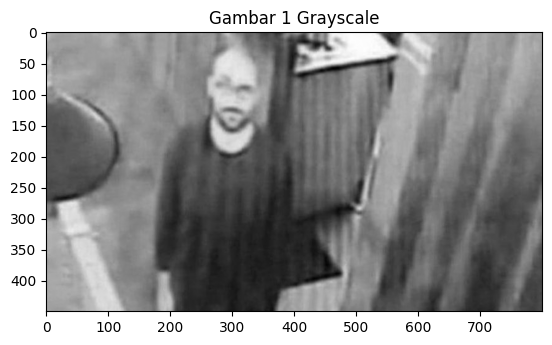

In [5]:
backup = cv2.imread('backup.jpg')
backup_rgb = cv2.cvtColor(backup, cv2.COLOR_BGR2RGB)
backup_gray = cv2.cvtColor(backup, cv2.COLOR_BGR2GRAY)

plt.imshow(backup_gray, cmap='gray')
plt.title('Gambar 1 Grayscale')
plt.show()

In [6]:
def filtering(img, size, mode):
    h, w = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            area = size * size
            for i in range(h):
                for j in range(w):
                    region = padded[i:i+size, j:j+size]

        case 'median':
            for i in range(h):
                for j in range(w):
                    region = padded[i:i+size, j:j+size]

        case 'modus':
            for i in range(h):
                for j in range(w):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()

                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1

                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val

                    canvas[i, j] = mode_val

    return canvas

In [8]:
def convolution(img, kernel):
    size = kernel.shape[0]

    pad_size = size // 2

    padded = np.pad(img, pad_size, mode='constant')

    canvas = np.zeros_like(img).astype(np.float32)

    h, w = img.shape

    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

In [9]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5, 1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

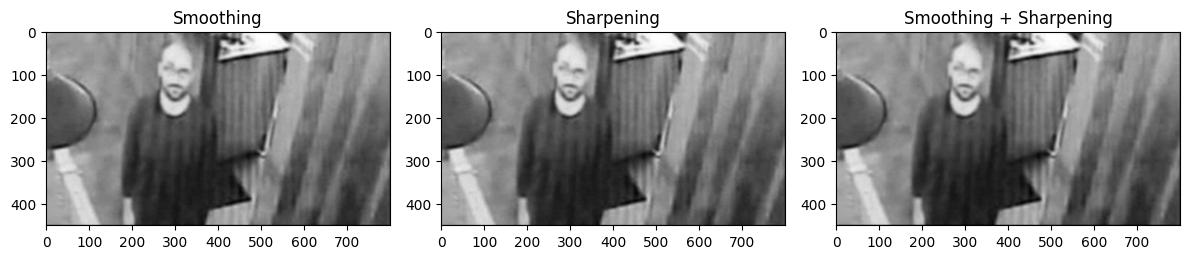

In [10]:
backup_gray_smoothing = convolution(backup_gray, kernelSmoothing)
backup_gray_sharpening = convolution(backup_gray, kernelSharpening)
backup_gray_smoothing_sharpening = convolution(backup_gray_smoothing, kernelSharpening)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(backup_gray_smoothing, cmap='gray')
plt.title('Smoothing')

plt.subplot(1, 3, 2)
plt.imshow(backup_gray_sharpening, cmap='gray')
plt.title('Sharpening')

plt.subplot(1, 3, 3)
plt.imshow(backup_gray_smoothing_sharpening, cmap='gray')
plt.title('Smoothing + Sharpening')

plt.tight_layout()
plt.show()

In [11]:
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)

    canvas = np.zeros_like(img, dtype=np.float32)

    canvas = np.abs(gx) + np.abs(gy)

    canvas = canvas * 255 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

In [12]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

In [13]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])

In [14]:
robertsX = np.array([
    [1, 0],
    [0, -1]
])

robertsY =np.array([
    [0, 1],
    [-1, 0]
])

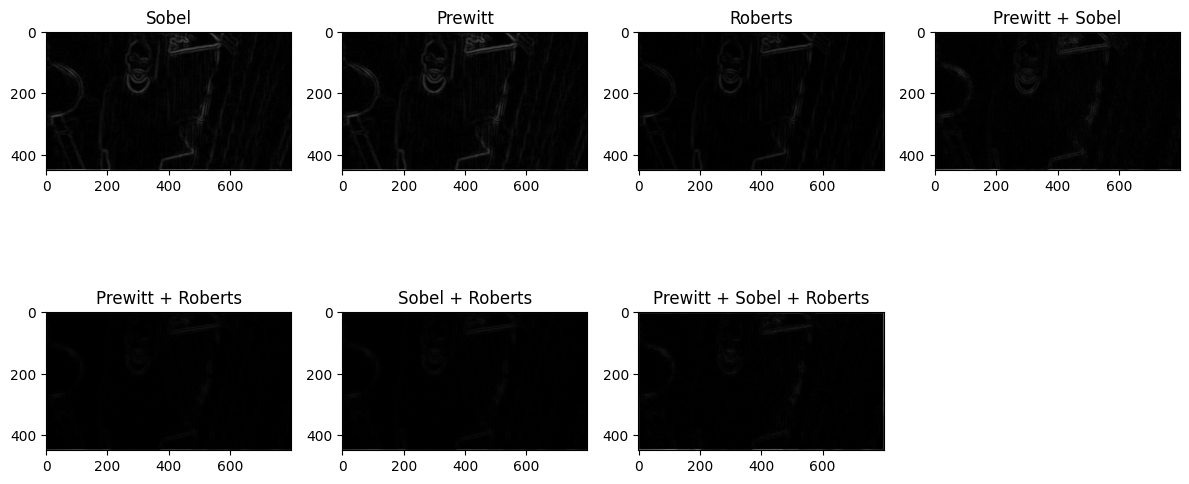

In [15]:
sobel = edge(backup_gray_smoothing_sharpening, sobelX, sobelY)
prewitt = edge(backup_gray_smoothing_sharpening, prewittX, prewittY)
roberts = edge(backup_gray_smoothing_sharpening, robertsX, robertsY)
prewitt_sobel = edge(prewitt, sobelX, sobelY)
prewitt_roberts = edge(prewitt, robertsX, robertsY)
sobel_roberts = edge(sobel, robertsX, robertsY)
prewitt_sobel_roberts = edge(prewitt_sobel, robertsX, robertsY)

plt.figure(figsize=(12, 6))
plt.subplot(2, 4, 1)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel')

plt.subplot(2, 4, 2)
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt')

plt.subplot(2, 4, 3)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts')

plt.subplot(2, 4, 4)
plt.imshow(prewitt_sobel, cmap='gray')
plt.title('Prewitt + Sobel')

plt.subplot(2, 4, 5)
plt.imshow(prewitt_roberts, cmap='gray')
plt.title('Prewitt + Roberts')

plt.subplot(2, 4, 6)
plt.imshow(sobel_roberts, cmap='gray')
plt.title('Sobel + Roberts')

plt.subplot(2, 4, 7)
plt.imshow(prewitt_sobel_roberts, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')

plt.tight_layout()
plt.show()